# 2. Automatic Correction / OCR

This section builds an OCR model for handwritten character recognition. The goal is to load the image dataset, prepare clean train/validation/test splits, train a CNN, and evaluate it with metrics that are useful for automatic correction.

## 2.1 Dataset Preparation

In [2]:
import json
import os
import pickle
import struct
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Disable oneDNN to make TensorFlow behavior more stable on my Windows setup.
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import SGDClassifier

try:
    RANDOM_STATE
except NameError:
    RANDOM_STATE = 42

# Paths to the OCR image files and class mapping.
OCR_DATA_DIR = Path("../student_dataset/image_data")
TRAIN_IMAGES_PATH = OCR_DATA_DIR / "train-images-idx3-ubyte"
TRAIN_LABELS_PATH = OCR_DATA_DIR / "train-labels-idx1-ubyte"
TEST_IMAGES_PATH = OCR_DATA_DIR / "test-images-idx3-ubyte"
TEST_LABELS_PATH = OCR_DATA_DIR / "test-labels-idx1-ubyte"
MAPPING_PATH = OCR_DATA_DIR / "mapping.txt"


def set_seed(seed=31415):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

# All generated tables, figures, models, and configs are saved in one OCR folder.
ARTIFACTS_DIR = Path("outputs/part2")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


def _artifact_path(filename, ext, folder=None):
    directory = ARTIFACTS_DIR if folder is None else ARTIFACTS_DIR / folder
    directory.mkdir(parents=True, exist_ok=True)
    return directory / f"{filename}.{ext}"


def save_table(df, filename, folder=None):
    if isinstance(df, pd.Series):
        df = df.to_frame()
    path = _artifact_path(filename, "csv", folder=folder)
    df.to_csv(path, index=False)
    return path


def save_figure(filename, folder=None, fig=None):
    if fig is None:
        fig = plt.gcf()
    path = _artifact_path(filename, "png", folder=folder)
    fig.savefig(path, bbox_inches="tight", dpi=160)
    return path


def save_model(model, filename, folder=None):
    if hasattr(model, "save"):
        path = _artifact_path(filename, "keras", folder=folder)
        model.save(path)
    else:
        path = _artifact_path(filename, "pkl", folder=folder)
        with open(path, "wb") as file:
            pickle.dump(model, file)
    return path


def save_json(payload, filename, folder=None):
    path = _artifact_path(filename, "json", folder=folder)
    with open(path, "w", encoding="utf-8") as file:
        json.dump(payload, file, indent=2, ensure_ascii=False)
    return path


print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


### 2.1.1 Load IDX Images and Character Mapping

The image files are stored in IDX binary format. After loading, the images are transposed to get the correct character orientation.

In [3]:
def load_idx_images(path):
    # IDX image files start with a small binary header before the pixel values.
    with open(path, "rb") as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
    images = images.reshape(num_images, rows, cols)

    # The dataset orientation needs this transpose to display characters correctly.
    images = np.transpose(images, (0, 2, 1)).copy()
    return images


def load_idx_labels(path):
    # Label files contain one integer class index per image.
    with open(path, "rb") as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels


def load_mapping(path):
    # The mapping file links each class index to its real character.
    mapping = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            class_index, ascii_code = line.split()
            mapping[int(class_index)] = chr(int(ascii_code))
    return mapping


class_mapping = load_mapping(MAPPING_PATH)
num_classes = len(class_mapping)

print(f"Number of OCR classes: {num_classes}")
print(class_mapping)

mapping_table = pd.DataFrame({
    "class_index": list(class_mapping.keys()),
    "character": list(class_mapping.values()),
})
save_table(mapping_table, "ocr_character_mapping", folder="2_1_1_load_idx_images_and_character_mapping")
save_json({str(k): v for k, v in class_mapping.items()}, "ocr_character_mapping", folder="2_1_1_load_idx_images_and_character_mapping")

Number of OCR classes: 62
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z', 36: 'a', 37: 'b', 38: 'c', 39: 'd', 40: 'e', 41: 'f', 42: 'g', 43: 'h', 44: 'i', 45: 'j', 46: 'k', 47: 'l', 48: 'm', 49: 'n', 50: 'o', 51: 'p', 52: 'q', 53: 'r', 54: 's', 55: 't', 56: 'u', 57: 'v', 58: 'w', 59: 'x', 60: 'y', 61: 'z'}


WindowsPath('outputs/part2/2_1_1_load_idx_images_and_character_mapping/ocr_character_mapping.json')

In [4]:
# Load the training and test datasets using the IDX format loaders.
train_images = load_idx_images(TRAIN_IMAGES_PATH)
train_labels = load_idx_labels(TRAIN_LABELS_PATH)
test_images = load_idx_images(TEST_IMAGES_PATH)
test_labels = load_idx_labels(TEST_LABELS_PATH)

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Pixel range: {train_images.min()} to {train_images.max()}")

# Create a summary table of the dataset shapes and save it.
ocr_dataset_summary = pd.DataFrame([
    {"split": "train", "images": len(train_images), "labels": len(train_labels), "height": train_images.shape[1], "width": train_images.shape[2]},
    {"split": "test", "images": len(test_images), "labels": len(test_labels), "height": test_images.shape[1], "width": test_images.shape[2]},
])
save_table(ocr_dataset_summary, "ocr_dataset_shapes", folder="2_1_1_load_idx_images_and_character_mapping")
ocr_dataset_summary

Train images shape: (697932, 28, 28)
Train labels shape: (697932,)
Test images shape: (116323, 28, 28)
Test labels shape: (116323,)
Pixel range: 0 to 255


,split,images,labels,height,width
0,train,697932,697932,28,28
1,test,116323,116323,28,28


### 2.1.2 Data Exploration

Before training, I inspect a few images and the class distribution. This helps check the image orientation and the imbalance between characters.

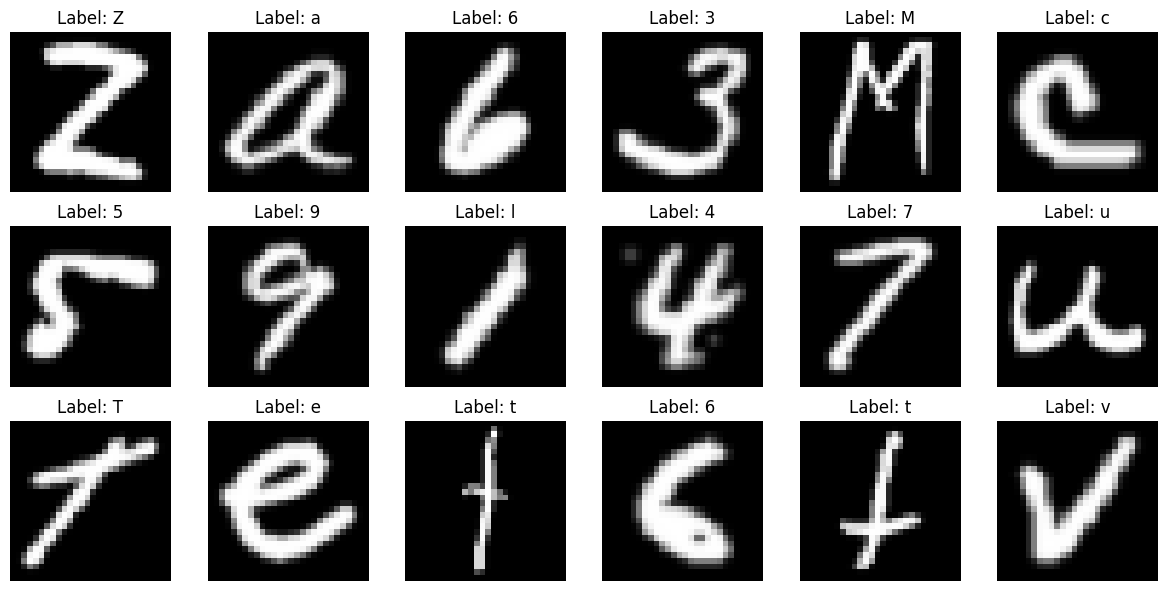

In [5]:
# Display the first images to check that labels and orientation are correct.
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
axes = axes.ravel()

for ax, idx in zip(axes, range(len(axes))):
    ax.imshow(train_images[idx], cmap="gray")
    ax.set_title(f"Label: {class_mapping[int(train_labels[idx])]}")
    ax.axis("off")

plt.tight_layout()
save_figure("ocr_sample_images", folder="2_1_2_data_exploration", fig=fig)
plt.show()

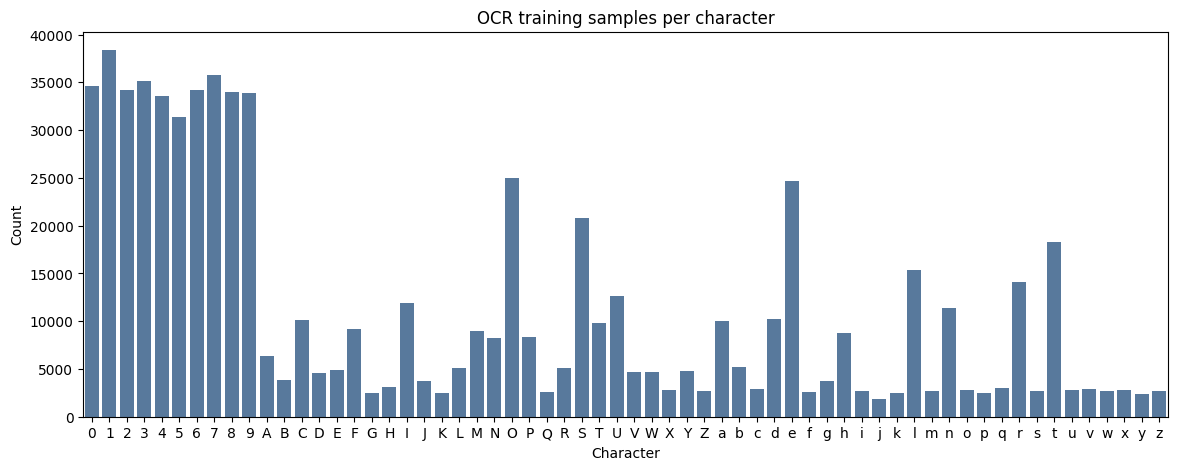

,class_count_summary
count,62.000000
mean,11256.967742
std,11558.910983
min,1896.000000
25%,2783.750000
50%,5074.500000
75%,13729.250000
max,38374.000000


In [5]:
# Count examples per character before balancing.
label_counts = pd.Series(train_labels).map(class_mapping).value_counts().sort_index()


# Plot the class distribution to make imbalance visible.
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, color="#4c78a8")
plt.title("OCR training samples per character")
plt.xlabel("Character")
plt.ylabel("Count")
save_figure("ocr_training_samples_per_character", folder="2_1_2_data_exploration", fig=fig)
plt.show()

save_table(label_counts.rename("training_count").reset_index().rename(columns={"index": "character"}), "ocr_label_counts", folder="2_1_2_data_exploration")
save_table(label_counts.describe().to_frame("class_count_summary"), "ocr_class_count_summary", folder="2_1_2_data_exploration")
label_counts.describe().to_frame("class_count_summary")

### 2.1.3 Train, Validation and Test Preparation

The images are reshaped with one channel, then split into training, validation, and test sets. The validation split is stratified so every character class stays represented.

The training data is also capped per class. This reduces the effect of very frequent classes while keeping the available examples for rarer classes.

In [6]:
# Add a channel dimension because Keras CNN layers expect image tensors with channels.
train_images_tf = np.expand_dims(train_images, axis=-1)
test_images_tf = np.expand_dims(test_images, axis=-1)

# I use a stratified split so the 62 classes stay represented in validation.
all_train_indices = np.arange(len(train_images_tf))
train_pool_indices, valid_indices = train_test_split(
    all_train_indices,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=train_labels,
)

rng = np.random.default_rng(RANDOM_STATE)
y_train_pool = train_labels[train_pool_indices]

# The original test set is kept separate and is only used for final evaluation.
X_valid_ocr = train_images_tf[valid_indices]
y_valid_ocr = train_labels[valid_indices]
X_test_ocr = test_images_tf
y_test_ocr = test_labels

print(f"Training examples: {len(train_pool_indices):,}")
print(f"Validation examples: {len(X_valid_ocr):,}")
print(f"Test examples: {len(X_test_ocr):,}")
print(f"Image shape used by Keras: {train_images_tf.shape[1:]}")


# Save the split sizes to document the dataset preparation.
ocr_split_summary = pd.DataFrame([
    {"split": "train_pool", "examples": len(train_pool_indices)},
    {"split": "validation", "examples": len(X_valid_ocr)},
    {"split": "test", "examples": len(X_test_ocr)},
])
save_table(ocr_split_summary, "ocr_split_summary", folder="2_1_3_train_validation_test_preparation")
ocr_split_summary

Training examples: 593,242
Validation examples: 104,690
Test examples: 116,323
Image shape used by Keras: (28, 28, 1)


,split,examples
0,train_pool,593242
1,validation,104690
2,test,116323


In [7]:
# Build TensorFlow datasets and reduce class imbalance before training.
USE_BALANCED_OCR_SAMPLE = True
MAX_EXAMPLES_PER_CLASS = 1_600 #4_000
BATCH_SIZE = 128
USE_TF_CACHE = False
AUTOTUNE = tf.data.AUTOTUNE

# The balanced sample avoids training mostly on frequent characters.
if USE_BALANCED_OCR_SAMPLE:
    balanced_indices = []
    for class_index in range(num_classes):
        class_indices = np.flatnonzero(y_train_pool == class_index)

        # Frequent classes are capped, while rare classes keep all their available examples.
        n_examples = min(MAX_EXAMPLES_PER_CLASS, len(class_indices))
        chosen_indices = rng.choice(class_indices, size=n_examples, replace=False)
        balanced_indices.append(chosen_indices)

    balanced_positions = rng.permutation(np.concatenate(balanced_indices))
    balanced_image_indices = train_pool_indices[balanced_positions]
    X_train_fit = train_images_tf[balanced_image_indices]
    y_train_fit = train_labels[balanced_image_indices]
else:
    X_train_fit = train_images_tf[train_pool_indices]
    y_train_fit = y_train_pool

train_fit_counts = pd.Series(y_train_fit).map(class_mapping).value_counts().sort_index()
fit_distribution = pd.DataFrame({
    "character": train_fit_counts.index,
    "training_count": train_fit_counts.values,
})

# The datasets are batched first, then normalized in the map step.
ds_train_ = tf.data.Dataset.from_tensor_slices((X_train_fit, y_train_fit)).shuffle(
    buffer_size=min(len(X_train_fit), 20_000),
    seed=RANDOM_STATE,
).batch(BATCH_SIZE)

ds_valid_ = tf.data.Dataset.from_tensor_slices((X_valid_ocr, y_valid_ocr)).batch(BATCH_SIZE)
ds_test_ = tf.data.Dataset.from_tensor_slices((X_test_ocr, y_test_ocr)).batch(BATCH_SIZE)


def convert_to_float(image, label):
    # Normalize pixel values to [0, 1] and convert to float32 for Keras.
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)
    return image, label


def prepare_dataset(dataset):
    dataset = dataset.map(convert_to_float, num_parallel_calls=AUTOTUNE)
    if USE_TF_CACHE:
        dataset = dataset.cache()
    return dataset.prefetch(AUTOTUNE)


ds_train = prepare_dataset(ds_train_)
ds_valid = prepare_dataset(ds_valid_)
ds_test = prepare_dataset(ds_test_)

print(f"Training examples used by model: {len(X_train_fit):,}")
print(f"Smallest class in training fit set: {train_fit_counts.min():,}")
print(f"Largest class in training fit set: {train_fit_counts.max():,}")
save_table(fit_distribution, "ocr_balanced_training_distribution", folder="2_1_3_train_validation_test_preparation")
save_json({"use_balanced_sample": USE_BALANCED_OCR_SAMPLE, "max_examples_per_class": MAX_EXAMPLES_PER_CLASS, "batch_size": BATCH_SIZE, "use_tf_cache": USE_TF_CACHE}, "ocr_training_dataset_config", folder="2_1_3_train_validation_test_preparation")

# Show the capped distribution to verify the balancing step.
display(fit_distribution.describe(include="all"))
display(fit_distribution.sort_values("training_count").head(12))

Training examples used by model: 99,200
Smallest class in training fit set: 1,600
Largest class in training fit set: 1,600


,character,training_count
count,62,62.0
unique,62,NaN
top,0,NaN
freq,1,NaN
mean,NaN,1600.0
std,NaN,0.0
min,NaN,1600.0
25%,NaN,1600.0
50%,NaN,1600.0
75%,NaN,1600.0


,character,training_count
0,0,1600
1,1,1600
2,2,1600
3,3,1600
4,4,1600
5,5,1600
6,6,1600
7,7,1600
8,8,1600
9,9,1600


## 2.2 Model Choice and Training

I first evaluate two simple baselines: a most-frequent classifier and a linear classifier on flattened pixels. Then I train a CNN because OCR images contain local shapes such as lines, curves, and corners.

In [8]:
# I cap the baseline data to keep this comparison fast.
def select_capped_indices(source_indices, labels, max_per_class, seed=RANDOM_STATE):
    rng_local = np.random.default_rng(seed)
    selected = []

    for class_index in range(num_classes):
        class_indices = source_indices[labels[source_indices] == class_index]
        n_selected = min(max_per_class, len(class_indices))
        if n_selected > 0:
            selected.append(rng_local.choice(class_indices, size=n_selected, replace=False))

    return rng_local.permutation(np.concatenate(selected))


BASELINE_MAX_TRAIN_PER_CLASS = 500
BASELINE_MAX_VALID_PER_CLASS = 250


# Select a small but balanced subset for the baseline comparison.
baseline_train_indices = select_capped_indices(
    train_pool_indices,
    train_labels,
    max_per_class=BASELINE_MAX_TRAIN_PER_CLASS,
    seed=RANDOM_STATE + 1,
)

baseline_valid_indices = select_capped_indices(
    valid_indices,
    train_labels,
    max_per_class=BASELINE_MAX_VALID_PER_CLASS,
    seed=RANDOM_STATE + 2,
)

X_baseline_train = train_images[baseline_train_indices].reshape(len(baseline_train_indices), -1).astype("float32") / 255.0
y_baseline_train = train_labels[baseline_train_indices]

X_baseline_valid = train_images[baseline_valid_indices].reshape(len(baseline_valid_indices), -1).astype("float32") / 255.0
y_baseline_valid = train_labels[baseline_valid_indices]

# These baselines do not use the 2D image structure.
baseline_models = {
    "Dummy most frequent": DummyClassifier(strategy="most_frequent"),
    "Linear SGD classifier": SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        max_iter=25,
        tol=1e-3,
        early_stopping=True,
        n_iter_no_change=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

baseline_results = []

for model_name, baseline_model in baseline_models.items():
    baseline_model.fit(X_baseline_train, y_baseline_train)
    valid_pred = baseline_model.predict(X_baseline_valid)

        # Store the same metrics for each baseline.
baseline_results.append({
        "model": model_name,
        "validation_accuracy": accuracy_score(y_baseline_valid, valid_pred),
        "validation_balanced_accuracy": balanced_accuracy_score(y_baseline_valid, valid_pred),
        "validation_macro_f1": f1_score(y_baseline_valid, valid_pred, average="macro"),
    })

baseline_results_df = pd.DataFrame(baseline_results)
save_table(baseline_results_df.round(4), "ocr_baseline_results", folder="2_2_model_choice_and_training")
baseline_results_df.round(4)

,model,validation_accuracy,validation_balanced_accuracy,validation_macro_f1
0,Linear SGD classifier,0.4545,0.4545,0.4485


### 2.2.1 CNN Architecture and Training

The network uses small augmentation layers, convolution blocks, dropout, batch normalization, early stopping, and learning-rate reduction. The output layer has 62 softmax units, one for each character class.

In [9]:
# Clear previous TensorFlow graphs before creating the model.
keras.backend.clear_session()

# The CNN keeps spatial information, unlike the flattened baseline models.
model = keras.Sequential([
    layers.Input(shape=[28, 28, 1]),

    # Small image changes make the model less sensitive to handwriting variation.
    # Horizontal flips are not used because they can change a character.
    # The augmentation is small because OCR characters should not be distorted too much.
    layers.RandomRotation(0.04),
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
    layers.RandomZoom(0.05),
    layers.RandomContrast(0.10),

    # First convolution block.
    # Convolution layers learn local patterns such as edges and curves.
    layers.Conv2D(filters=32, kernel_size=3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(filters=32, kernel_size=3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    # Pooling reduces image size while keeping the main visual patterns.
    layers.MaxPool2D(pool_size=2),
    # Dropout helps reduce overfitting.
    layers.Dropout(0.05),

    # Second convolution block.
    layers.Conv2D(filters=64, kernel_size=3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(filters=64, kernel_size=3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPool2D(pool_size=2),
    layers.Dropout(0.10),

    # Third convolution block.
    layers.Conv2D(filters=128, kernel_size=3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(filters=128, kernel_size=3, padding="same", use_bias=False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPool2D(pool_size=2),
    layers.Dropout(0.15),

    # Dense classifier head.
    layers.Flatten(),
    layers.Dense(units=256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),
    # Softmax returns one probability for each OCR class.
    layers.Dense(units=num_classes, activation="softmax"),
])

model.summary()
save_json({"model_json": model.to_json()}, "ocr_cnn_architecture", folder="2_2_1_cnn_architecture_and_training")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 28, 28, 1)      │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 599,902 (2.29 MB)

 Trainable params: 598,494 (2.28 MB)

 Non-trainable params: 1,408 (5.50 KB)

WindowsPath('outputs/part2/2_2_1_cnn_architecture_and_training/ocr_cnn_architecture.json')

In [10]:
# Compile the model with a multiclass loss for integer labels.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    # Sparse accuracy is used because labels are integer class ids.
    metrics=["sparse_categorical_accuracy"],
    jit_compile=False,
)

In [ ]:
# Number of epochs is set high to allow for early stopping based on validation performance.
EPOCHS = 20 #30

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_fit,
)
# Convert class weights to the dictionary format expected by Keras.
class_weight_dict = dict(enumerate(class_weight_values.astype(float)))

# Save the best validation model and the training log.
checkpoint_path = _artifact_path("best_ocr_cnn_dropout1600", "keras", folder="2_2_1_cnn_architecture_and_training")
training_log_path = _artifact_path("ocr_training_log_dropout1600", "csv", folder="2_2_1_cnn_architecture_and_training")

checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_sparse_categorical_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1,
)

csv_logger = keras.callbacks.CSVLogger(str(training_log_path))

# Stop if validation accuracy does not improve for several epochs.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_sparse_categorical_accuracy",
    patience=5,
    restore_best_weights=True,
)

# Lower the learning rate when validation loss stops improving.
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1,
)

history = model.fit(
    ds_train,
    validation_data=ds_valid,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr, checkpoint, csv_logger],
    class_weight=class_weight_dict,
    verbose=1,
)


# Save the training history for plots and later reporting.
history_frame = pd.DataFrame(history.history)
save_table(history_frame.reset_index(names="epoch"), "ocr_training_history", folder="2_2_1_cnn_architecture_and_training")
save_model(model, "ocr_cnn_model", folder="2_2_1_cnn_architecture_and_training")
save_json(
    {
        "epochs": EPOCHS,
        "checkpoint_path": str(checkpoint_path),
        "training_log_path": str(training_log_path),
        "early_stopping_patience": 5,
        "reduce_lr_patience": 2,
    },
    "ocr_training_config",
    folder="2_2_1_cnn_architecture_and_training",
)
history_frame.loc[:, ["loss", "val_loss", "sparse_categorical_accuracy", "val_sparse_categorical_accuracy"]]

Epoch 1/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 1.6013 - sparse_categorical_accuracy: 0.5280
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.75169, saving model to outputs\part2\2_2_1_cnn_architecture_and_training\best_ocr_cnn_dropout4000.keras

Epoch 1: finished saving model to outputs\part2\2_2_1_cnn_architecture_and_training\best_ocr_cnn_dropout4000.keras
775/775 ━━━━━━━━━━━━━━━━━━━━ 264s 335ms/step - loss: 1.0606 - sparse_categorical_accuracy: 0.6359 - val_loss: 0.6200 - val_sparse_categorical_accuracy: 0.7517 - learning_rate: 0.0010
Epoch 2/20
775/775 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - loss: 0.7215 - sparse_categorical_accuracy: 0.7109
Epoch 2: val_sparse_categorical_accuracy improved from 0.75169 to 0.78656, saving model to outputs\part2\2_2_1_cnn_architecture_and_training\best_ocr_cnn_dropout4000.keras

Epoch 2: finished saving model to outputs\part2\2_2_1_cnn_architecture_and_training\best_ocr_cnn_dropout4000.keras
775/775 ━━━━━━━━━━━━━━━━━━━━ 2

,loss,val_loss,sparse_categorical_accuracy,val_sparse_categorical_accuracy
0,1.060594,0.620043,0.635867,0.751686
1,0.699240,0.556902,0.715817,0.786560
2,0.643739,0.517766,0.729849,0.789913
3,0.617710,0.497243,0.737984,0.808262
4,0.597419,0.570839,0.743992,0.767561
5,0.583556,0.503760,0.749083,0.791021
6,0.544950,0.506197,0.761401,0.787716
7,0.533268,0.487520,0.767873,0.810526
8,0.528610,0.466174,0.769315,0.818330
9,0.521662,0.454411,0.770665,0.819314


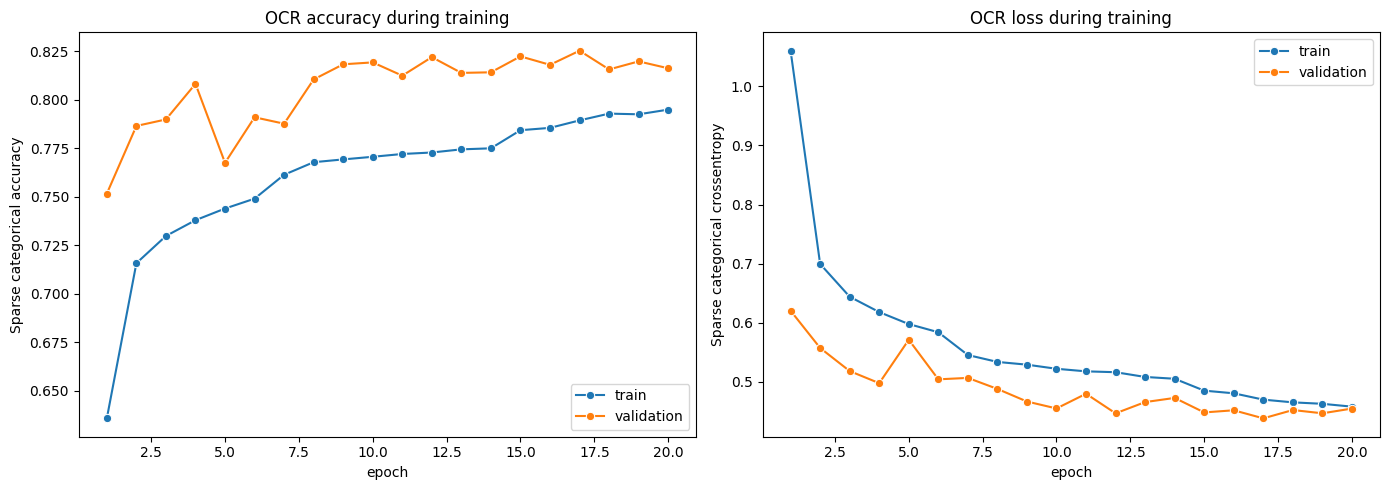

In [12]:
history_plot = history_frame.reset_index().rename(columns={"index": "epoch"})
history_plot["epoch"] = history_plot["epoch"] + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Compare train and validation curves on the same figure.
sns.lineplot(data=history_plot, x="epoch", y="sparse_categorical_accuracy", marker="o", label="train", ax=axes[0])
sns.lineplot(data=history_plot, x="epoch", y="val_sparse_categorical_accuracy", marker="o", label="validation", ax=axes[0])
axes[0].set_title("OCR accuracy during training")
axes[0].set_ylabel("Sparse categorical accuracy")

sns.lineplot(data=history_plot, x="epoch", y="loss", marker="o", label="train", ax=axes[1])
sns.lineplot(data=history_plot, x="epoch", y="val_loss", marker="o", label="validation", ax=axes[1])
axes[1].set_title("OCR loss during training")
axes[1].set_ylabel("Sparse categorical crossentropy")

plt.tight_layout()
save_figure("ocr_training_curves", folder="2_2_1_cnn_architecture_and_training", fig=fig)
plt.show()

## 2.3 Evaluation and Error Analysis

The model is evaluated with accuracy, balanced accuracy, F1 scores, top-3 accuracy, and a confusion matrix. These metrics are useful because the OCR task has many classes and class imbalance.

In [13]:
# Top-3 accuracy checks whether the correct class is among the three best guesses.
def sparse_top_k_accuracy(y_true, probabilities, k=3):
    top_k = np.argsort(probabilities, axis=1)[:, -k:]
    return np.mean([
        true_label in predicted_top_k
        for true_label, predicted_top_k in zip(y_true, top_k)
    ])


test_loss, test_accuracy = model.evaluate(ds_test, verbose=0)
valid_probabilities = model.predict(ds_valid, verbose=0)
valid_predictions = valid_probabilities.argmax(axis=1)
test_probabilities = model.predict(ds_test, verbose=0)
test_predictions = test_probabilities.argmax(axis=1)
test_true_labels = y_test_ocr

target_names = [class_mapping[i] for i in range(num_classes)]

# I keep validation and test metrics in one table for comparison.
metrics_summary = pd.DataFrame([
    {
        "split": "validation",
        "loss": np.nan,
        "accuracy": accuracy_score(y_valid_ocr, valid_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_valid_ocr, valid_predictions),
        "macro_f1": f1_score(y_valid_ocr, valid_predictions, average="macro"),
        "weighted_f1": f1_score(y_valid_ocr, valid_predictions, average="weighted"),
        "top3_accuracy": sparse_top_k_accuracy(y_valid_ocr, valid_probabilities, k=3),
    },
    {
        "split": "test",
        "loss": test_loss,
        "accuracy": accuracy_score(test_true_labels, test_predictions),
        "balanced_accuracy": balanced_accuracy_score(test_true_labels, test_predictions),
        "macro_f1": f1_score(test_true_labels, test_predictions, average="macro"),
        "weighted_f1": f1_score(test_true_labels, test_predictions, average="weighted"),
        "top3_accuracy": sparse_top_k_accuracy(test_true_labels, test_probabilities, k=3),
    },
])

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(classification_report(test_true_labels, test_predictions, target_names=target_names, zero_division=0))

report_dict = classification_report(
    test_true_labels,
    test_predictions,
    target_names=target_names,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report_dict).T

# The weakest classes help identify where the model still fails.
weakest_classes = report_df.loc[target_names].sort_values("f1-score").head(15)

save_table(metrics_summary.round(4), "ocr_metrics_summary", folder="2_3_evaluation_and_error_analysis")
save_table(report_df.reset_index(names="class_or_average"), "ocr_classification_report", folder="2_3_evaluation_and_error_analysis")
save_table(weakest_classes.reset_index(names="character"), "ocr_weakest_classes", folder="2_3_evaluation_and_error_analysis")

display(metrics_summary.round(4))
display(weakest_classes)
display(report_df.loc[["macro avg", "weighted avg"]])

Test loss: 0.4347
Test accuracy: 0.8263
              precision    recall  f1-score   support

           0       0.69      0.77      0.73      5778
           1       0.73      0.65      0.68      6330
           2       0.99      0.87      0.93      5869
           3       1.00      0.99      0.99      5969
           4       0.99      0.95      0.97      5619
           5       0.93      0.96      0.94      5190
           6       0.99      0.93      0.96      5705
           7       0.99      0.99      0.99      6139
           8       0.99      0.97      0.98      5633
           9       0.96      0.88      0.92      5686
           A       0.94      0.99      0.97      1062
           B       0.90      0.99      0.94       648
           C       0.82      0.66      0.73      1739
           D       0.71      0.97      0.82       779
           E       0.93      0.99      0.96       851
           F       0.87      0.68      0.76      1440
           G       0.67      0.98      0.

,split,loss,accuracy,balanced_accuracy,macro_f1,weighted_f1,top3_accuracy
0,validation,NaN,0.8253,0.7779,0.7436,0.8316,0.9889
1,test,0.4347,0.8263,0.7782,0.7418,0.8327,0.9893


,precision,recall,f1-score,support
o,0.097594,0.313305,0.148828,466.0
s,0.148529,0.462243,0.224819,437.0
c,0.289203,0.520833,0.371901,432.0
i,0.307876,0.604215,0.407905,427.0
l,0.367930,0.467061,0.411611,2535.0
u,0.367069,0.504149,0.424825,482.0
O,0.696809,0.346728,0.463046,4156.0
z,0.489051,0.445676,0.466357,451.0
q,0.388235,0.588119,0.467717,505.0
f,0.351485,0.710000,0.470199,400.0


,precision,recall,f1-score,support
macro avg,0.735469,0.778215,0.741781,116323.0
weighted avg,0.854260,0.826303,0.832726,116323.0


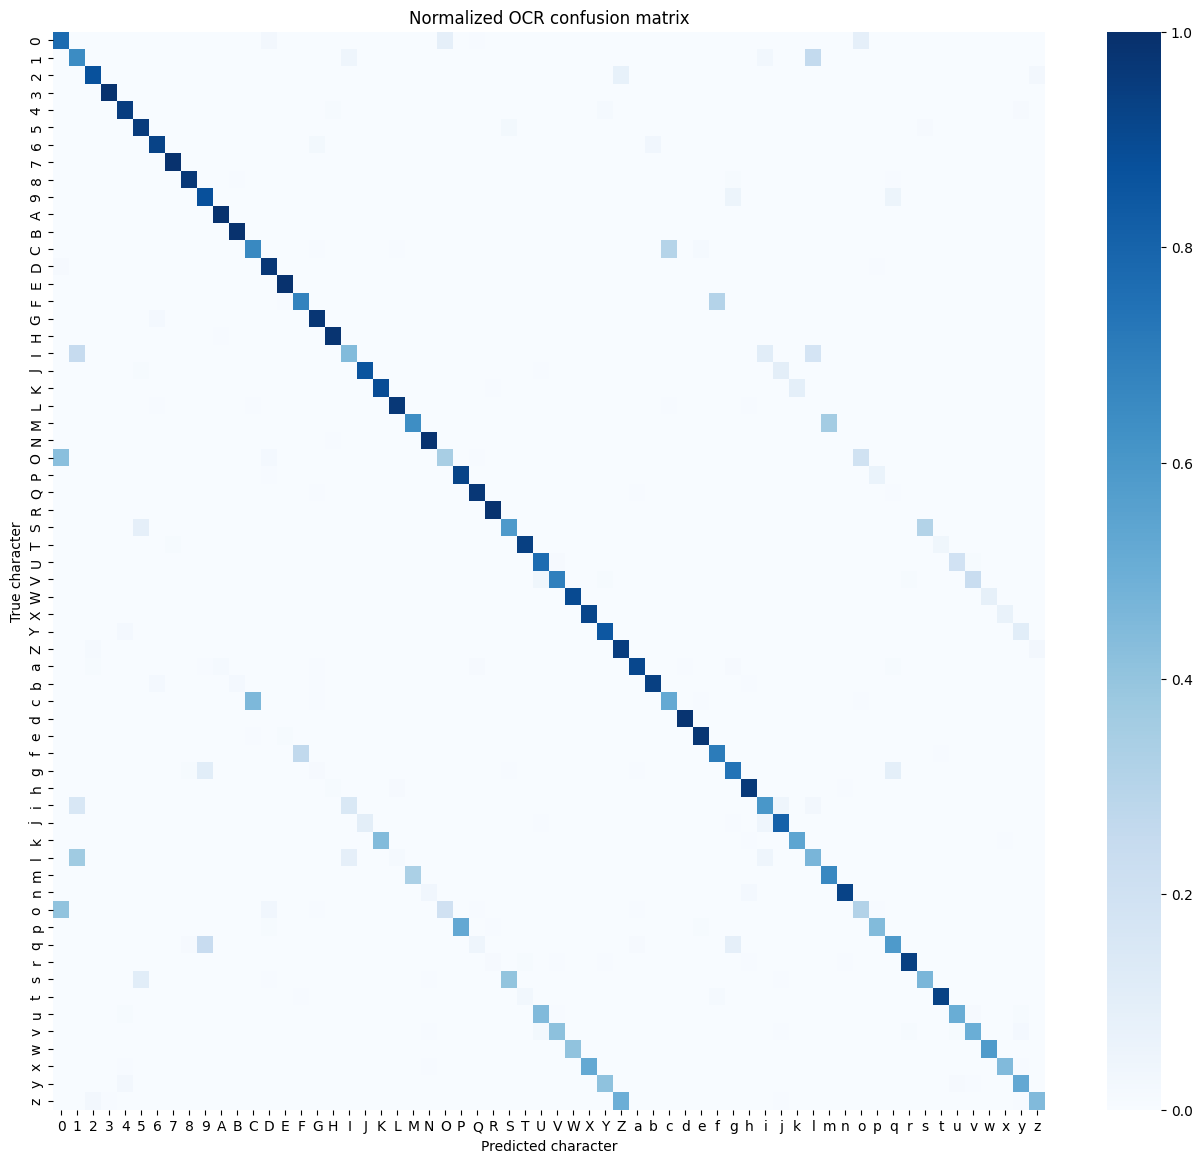

In [14]:
cm = confusion_matrix(test_true_labels, test_predictions, labels=list(range(num_classes)))
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 14))
# Use a heatmap because the OCR task has many classes.
sns.heatmap(cm_normalized, cmap="Blues", xticklabels=target_names, yticklabels=target_names, vmin=0, vmax=1, ax=ax)
plt.title("Normalized OCR confusion matrix")
plt.xlabel("Predicted character")
plt.ylabel("True character")
save_table(pd.DataFrame(cm, index=target_names, columns=target_names).reset_index(names="true_character"), "ocr_confusion_matrix_counts", folder="2_3_evaluation_and_error_analysis")
save_table(pd.DataFrame(cm_normalized, index=target_names, columns=target_names).reset_index(names="true_character"), "ocr_confusion_matrix_normalized", folder="2_3_evaluation_and_error_analysis")
save_figure("ocr_confusion_matrix_normalized", folder="2_3_evaluation_and_error_analysis", fig=fig)
plt.show()

In [28]:
confusions = []
true_character_counts = cm.sum(axis=1)

for true_idx in range(num_classes):
    for pred_idx in range(num_classes):
        if true_idx != pred_idx:
            confusion_count = cm[true_idx, pred_idx]
            true_count = true_character_counts[true_idx]
            confusions.append({
                "true_character": class_mapping[true_idx],
                "predicted_character": class_mapping[pred_idx],
                "count": confusion_count,
                "true_character_count": true_count,
                "confusion_rate": confusion_count / true_count if true_count > 0 else 0,
                "confusion_percentage": (confusion_count / true_count * 100) if true_count > 0 else 0,
            })


In [29]:
confusions = pd.DataFrame(confusions).loc[lambda df: df["count"] != 0].sort_values("count", ascending=False)
save_table(confusions, "ocr_confusions", folder="2_3_evaluation_and_error_analysis")
confusions.head(50)

,true_character,predicted_character,count,true_character_count,confusion_rate,confusion_percentage
1464,O,0,1761,4156,0.423725,42.372474
107,1,l,1655,6330,0.261453,26.145340
1761,S,s,1090,3508,0.310718,31.071836
2868,l,1,933,2535,0.368047,36.804734
1513,O,o,817,4156,0.196583,19.658325
1389,M,m,529,1485,0.356229,35.622896
769,C,c,528,1739,0.303623,30.362277
49,0,o,526,5778,0.091035,9.103496
23,0,O,525,5778,0.090862,9.086189
1099,I,1,515,2048,0.251465,25.146484


In [30]:
# Keep the largest confusion counts first.
confusions_true_character = pd.DataFrame(confusions).loc[lambda df: df["count"] != 0].sort_values("true_character", ascending=False)
save_table(confusions_true_character, "ocr_confusions_true_character", folder="2_3_evaluation_and_error_analysis")
confusions_true_character.head(50)

,true_character,predicted_character,count,true_character_count,confusion_rate,confusion_percentage
3756,z,Z,224,451,0.496674,49.667406
3724,z,3,3,451,0.006652,0.665188
3781,z,y,2,451,0.004435,0.443459
3766,z,j,2,451,0.004435,0.443459
3728,z,7,1,451,0.002217,0.221729
3729,z,8,1,451,0.002217,0.221729
3761,z,e,1,451,0.002217,0.221729
3773,z,q,1,451,0.002217,0.221729
3755,z,Y,1,451,0.002217,0.221729
3723,z,2,14,451,0.031042,3.104213


In [16]:
character_summary = []

for true_idx in range(num_classes):
    total_count = cm[true_idx].sum()
    correct_count = cm[true_idx, true_idx]
    false_count = total_count - correct_count

    character_summary.append({
        "true_character": class_mapping[true_idx],
        "total_true_character_count": int(total_count),
        "correct_count": int(correct_count),
        "correct_percentage": (correct_count / total_count * 100) if total_count > 0 else 0,
        "false_count": int(false_count),
        "false_percentage": (false_count / total_count * 100) if total_count > 0 else 0,
    })


# Sort by false percentage to see the hardest characters first.
character_summary_df = (
    pd.DataFrame(character_summary)
    .sort_values("false_percentage", ascending=False)
    .reset_index(drop=True)
)

save_table(character_summary_df, "ocr_per_character_summary", folder="2_3_evaluation_and_error_analysis")
character_summary_df

,true_character,total_true_character_count,correct_count,correct_percentage,false_count,false_percentage
0,o,466,146,31.330472,320,68.669528
1,O,4156,1441,34.672762,2715,65.327238
2,p,368,163,44.293478,205,55.706522
3,I,2048,910,44.433594,1138,55.566406
4,z,451,201,44.567627,250,55.432373
...,...,...,...,...,...,...
57,R,809,800,98.887515,9,1.112485
58,B,648,641,98.919753,7,1.080247
59,E,851,843,99.059929,8,0.940071
60,3,5969,5916,99.112079,53,0.887921


### 2.3.1 Confidence Analysis

For automatic correction, confidence is important. High-confidence predictions can be accepted more easily, while low-confidence predictions should be checked manually.

In [17]:
# Group characters to compare digits, uppercase, and lowercase symbols.
def character_group(character):
    if character.isdigit():
        return "digit"
    if character.isupper():
        return "uppercase"
    if character.islower():
        return "lowercase"
    return "other"


# Confidence is the highest predicted probability for each image.
test_confidence = test_probabilities.max(axis=1)

# Keep each test prediction with its confidence for later filtering.
test_results = pd.DataFrame({
    "true_class": test_true_labels,
    "predicted_class": test_predictions,
    "true_character": [class_mapping[int(label)] for label in test_true_labels],
    "predicted_character": [class_mapping[int(label)] for label in test_predictions],
    "confidence": test_confidence,
})

test_results["correct"] = test_results["true_class"] == test_results["predicted_class"]
test_results["true_group"] = test_results["true_character"].map(character_group)

# Compare performance for digits, uppercase letters, and lowercase letters.
group_metrics = (
    test_results
    .groupby("true_group")
    .agg(
        support=("correct", "size"),
        accuracy=("correct", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

# Different thresholds show the trade-off between automation and manual review.
threshold_rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.98]:
    automatic_mask = test_results["confidence"] >= threshold
    threshold_rows.append({
        "confidence_threshold": threshold,
        "automatic_coverage": automatic_mask.mean(),
        "manual_review_rate": 1 - automatic_mask.mean(),
        "accuracy_on_automatic_predictions": test_results.loc[automatic_mask, "correct"].mean() if automatic_mask.any() else np.nan,
        "n_automatic_predictions": int(automatic_mask.sum()),
    })

threshold_table = pd.DataFrame(threshold_rows)

save_table(test_results, "ocr_test_predictions", folder="2_3_1_confidence_analysis")
save_table(group_metrics.round(4), "ocr_group_metrics", folder="2_3_1_confidence_analysis")
save_table(threshold_table.round(4), "ocr_confidence_thresholds", folder="2_3_1_confidence_analysis")

display(group_metrics.round(4))
display(threshold_table.round(4))

,true_group,support,accuracy,mean_confidence
0,digit,57918,0.8918,0.8511
1,lowercase,27059,0.7925,0.8421
2,uppercase,31346,0.7345,0.7585


,confidence_threshold,automatic_coverage,manual_review_rate,accuracy_on_automatic_predictions,n_automatic_predictions
0,0.50,0.8870,0.1130,0.8716,103180
1,0.60,0.7762,0.2238,0.9156,90292
2,0.70,0.6967,0.3033,0.9455,81046
3,0.80,0.6303,0.3697,0.9654,73321
4,0.90,0.5648,0.4352,0.9800,65698
5,0.95,0.5171,0.4829,0.9874,60146
6,0.98,0.4630,0.5370,0.9917,53858


In [33]:
# Summarize the final train/validation gaps to flag overfitting or underfitting.
diagnostic_rows = []
for metric_name, train_column, validation_column in [
    ("accuracy", "sparse_categorical_accuracy", "val_sparse_categorical_accuracy"),
    ("loss", "loss", "val_loss"),
]:
    train_series = history_frame[train_column].dropna()
    validation_series = history_frame[validation_column].dropna()
    final_train = float(train_series.iloc[-1])
    final_validation = float(validation_series.iloc[-1])

    if metric_name == "accuracy":
        gap = final_train - final_validation
    else:
        gap = final_validation - final_train

    diagnostic_rows.append({
        "metric": metric_name,
        "final_train": final_train,
        "final_validation": final_validation,
        "gap": gap,
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)
save_table(diagnostic_df.round(4), "ocr_over_underfitting_check", folder="2_2_1_cnn_architecture_and_training")
display(diagnostic_df.round(4))

accuracy_gap = diagnostic_df.loc[diagnostic_df["metric"] == "accuracy", "gap"].iloc[0]
loss_gap = diagnostic_df.loc[diagnostic_df["metric"] == "loss", "gap"].iloc[0]

if accuracy_gap > 0.05:
    print("Possible overfitting: training accuracy is clearly higher than validation accuracy.")
elif abs(accuracy_gap) < 0.02 and abs(loss_gap) < 0.05:
    print("No strong overfitting signal: train and validation metrics stay close.")
else:
    print("The curves should still be checked visually, but there is no severe overfitting or underfitting signal from the final gap.")

,metric,final_train,final_validation,gap
0,accuracy,0.7950,0.8163,-0.0213
1,loss,0.4575,0.4543,-0.0032


The curves should still be checked visually, but there is no severe overfitting or underfitting signal from the final gap.


### 2.3.2 Most Confident OCR Errors

I also inspect wrong predictions with high confidence. These errors are important because the model is wrong but still certain.

Errors on test set: 20,205 / 116,323


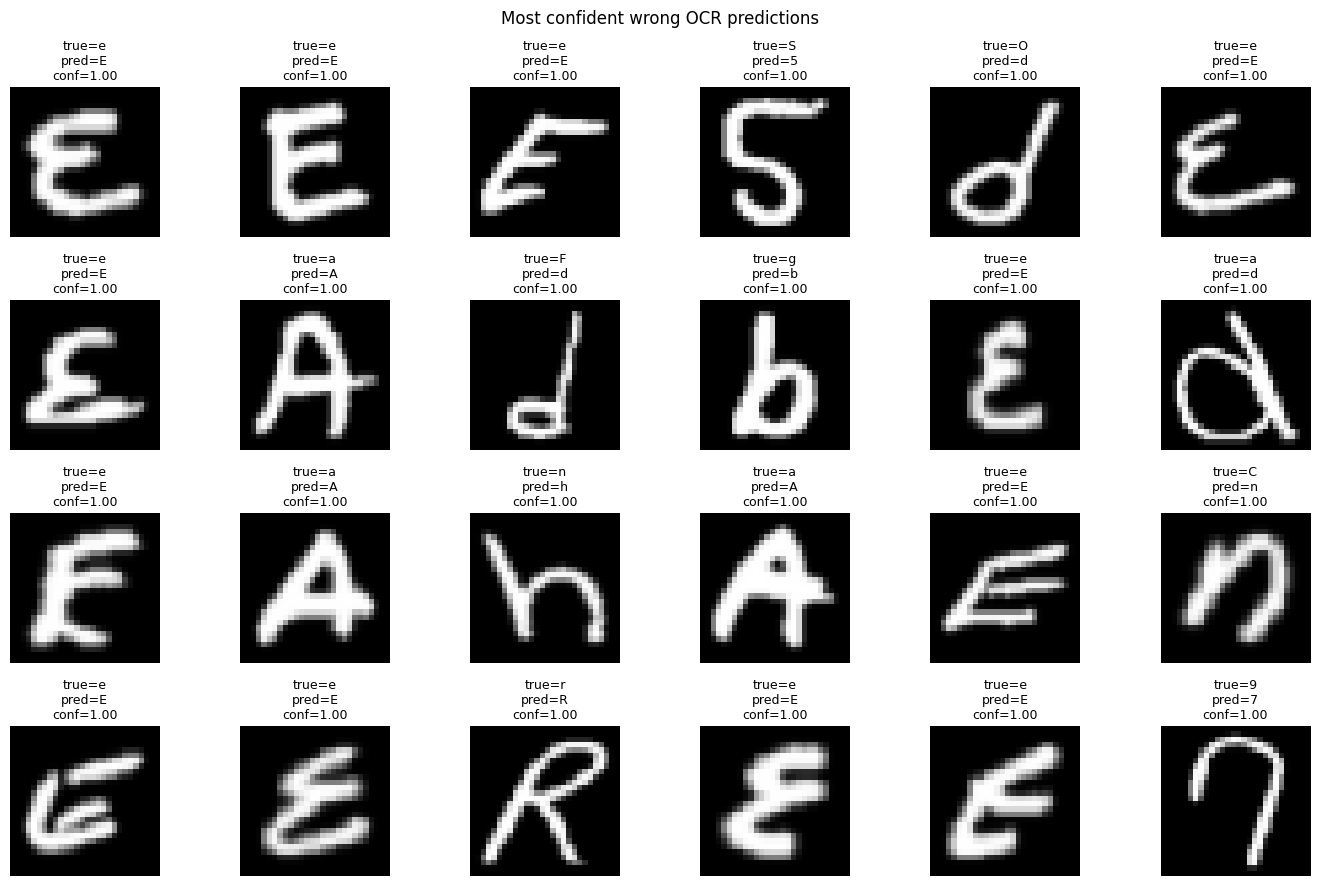

In [18]:
# Select only wrong predictions before ranking them by confidence.
wrong_indices = np.flatnonzero(test_predictions != test_true_labels)

print(f"Errors on test set: {len(wrong_indices):,} / {len(test_true_labels):,}")

if len(wrong_indices) > 0:
    # The most confident mistakes are the most risky for automatic correction.
    hardest_wrong = wrong_indices[np.argsort(test_confidence[wrong_indices])[-24:]][::-1]

    # Display a fixed grid of the most confident mistakes.
    fig, axes = plt.subplots(4, 6, figsize=(14, 9))
    axes = axes.ravel()

    for ax, idx in zip(axes, hardest_wrong):
        ax.imshow(test_images[idx], cmap="gray")
        title = (
            f"true={class_mapping[int(test_true_labels[idx])]}\n"
            f"pred={class_mapping[int(test_predictions[idx])]}\n"
            f"conf={test_confidence[idx]:.2f}"
        )
        ax.set_title(title, fontsize=9)
        ax.axis("off")

    for ax in axes[len(hardest_wrong):]:
        ax.axis("off")

    plt.suptitle("Most confident wrong OCR predictions")
    plt.tight_layout()
    save_figure("ocr_most_confident_wrong_predictions", folder="2_3_2_most_confident_ocr_errors", fig=fig)
    plt.show()

## 2.4 Results

This OCR pipeline loads the IDX images, prepares a stratified split, handles class imbalance, trains a CNN, and evaluates the final model. The main points to discuss in the report are the final test metrics, the weakest classes, the most common confusions, the training curves, and the confidence threshold for automatic correction.

In [31]:
best_test_row = metrics_summary.loc[metrics_summary["split"] == "test"].iloc[0]
top_5_confusions = confusions.head(5)[["true_character", "predicted_character", "count", "confusion_percentage"]]

report_conclusion = (
    f"The OCR model was trained on a balanced capped subset with up to {MAX_EXAMPLES_PER_CLASS:,} examples per class.\n"
    f"The final CNN obtained a test accuracy of {best_test_row['accuracy']:.4f}, "
    f"a balanced accuracy of {best_test_row['balanced_accuracy']:.4f}, "
    f"a macro F1-score of {best_test_row['macro_f1']:.4f}, "
    f"a weighted F1-score of {best_test_row['weighted_f1']:.4f}, "
    f"and a top-3 accuracy of {best_test_row['top3_accuracy']:.4f}.\n"
    "The confusion matrix shows that most errors occur between visually similar characters.\n"
    "For automatic correction, confidence thresholding can automatically accept high-confidence predictions and send uncertain cases to manual review."
)


# Save the generated conclusion and the main confusion pairs.
save_json({"ocr_conclusion": report_conclusion}, "ocr_conclusion", folder="2_4_results")
save_table(top_5_confusions, "ocr_top_5_confusions_for_report", folder="2_4_results")

print("OCR conclusion:")
print(report_conclusion)
display(top_5_confusions)

OCR conclusion:
The OCR model was trained on a balanced capped subset with up to 1,600 examples per class.
The final CNN obtained a test accuracy of 0.8263, a balanced accuracy of 0.7782, a macro F1-score of 0.7418, a weighted F1-score of 0.8327, and a top-3 accuracy of 0.9893.
The confusion matrix shows that most errors occur between visually similar characters.
For automatic correction, confidence thresholding can automatically accept high-confidence predictions and send uncertain cases to manual review.


,true_character,predicted_character,count,confusion_percentage
1464,O,0,1761,42.372474
107,1,l,1655,26.145340
1761,S,s,1090,31.071836
2868,l,1,933,36.804734
1513,O,o,817,19.658325
